In [ ]:
#!/usr/bin/python
#george test 07/31

%matplotlib inline

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy.stats as st

import seaborn as sns

#ipython magic to make module autoreload
%load_ext autoreload
%autoreload 2

import pwl_module_v5 as pwlm

import warnings
warnings.filterwarnings(action='once')


In [6]:
#read data

ptid = '7735_Wk14_vs_BL' #7710

df = pd.read_csv(f'for_dan_{ptid}.csv')


In [82]:
#calculaet some additionals
# 

c0 = df['counts_pre'].values
c1 = df['counts_post'].values

p0 = c0/np.sum(c0)
p1 = c1/np.sum(c1)

lp0 = np.log10(p0[p0>0])
lp1 = np.log10(p1[p1>0])


In [102]:
#pwl fit parameters

### consistent fitting parameters

objf  = 'RMS'           #objective function
ms    = '10'            #number of replicates
objs  = 'multimin_'+ms  #objective sampling scheme - specifies the number of replicates also
rmaxTCR  = 'nonsingle'  #which ranks to choose for TCR data
nfits = 1               #parametera value averages (from top X of error model)

model = 'pwl1'
gsize = 20 #for each param, finer pwl2 fitting since more parameters
TR     = 5 
ss     = 1e4 


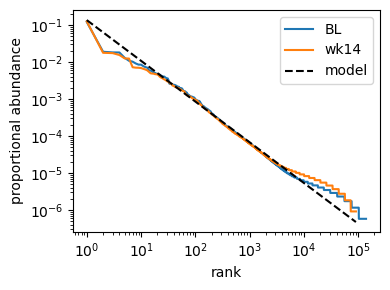

In [108]:
#ranbk abund
# 

tpname = ['BL','wk14']

plt.figure(figsize=(4,3))

for i,ci in enumerate([c0,c1]):

    ecol = pwlm.calc_ecol(ci)

    r,a,pa,cpa,R,D1,D2,N,d0,d1,d2,maxclone,top10clones,clonalf = ecol
    plt.loglog(r,pa,label=tpname[i])

    model_properties = ss, model, objf, rmaxTCR, objs, gsize, nfits
    #pwlm.gsearch_fitp(model_properties, a) #get this to work?

pamodel = r**(-1.1)
pamodel = pamodel/np.sum(pamodel)
plt.plot(r,pamodel,label='model',color='k',ls='--')

plt.xlabel('rank')
plt.ylabel('proportional abundance')
plt.legend()
plt.tight_layout()


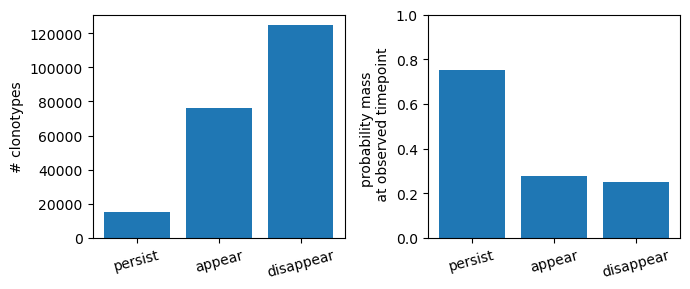

In [95]:
#categorize
# 

catclones = {
    'persist': np.sum((p0 > 0) & (p1 > 0)),
    'appear': np.sum((p0 == 0) & (p1 > 0)),
    'disappear': np.sum((p0 > 0) & (p1 == 0)),
}
catprob = {
    'persist':np.sum(p0[(p0 > 0) & (p1 > 0)]),
    'appear': np.sum(p1[(p0 == 0) & (p1 > 0)]),
    'disappear': np.sum(p0[(p0 > 0) & (p1 == 0)]),
}

plt.figure(figsize=(7,3))
plt.subplot(1,2,1)
plt.bar(catclones.keys(), catclones.values())
plt.ylabel('# clonotypes')
plt.xticks(rotation=15)

plt.subplot(1,2,2)
plt.bar(catprob.keys(), catprob.values())
plt.ylabel('probability mass \n at observed timepoint')
plt.xticks(rotation=15)
plt.ylim(0,1)
#plt.semilogy()

plt.tight_layout()

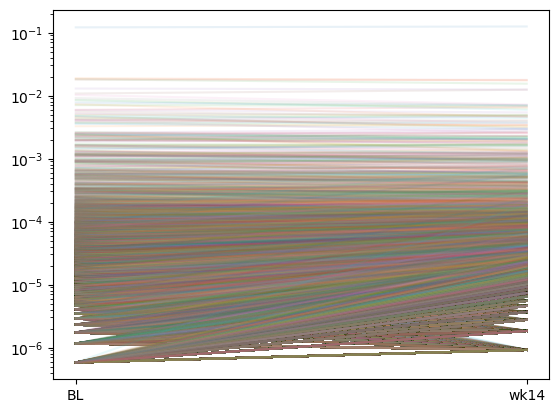

In [97]:
#sns.violinplot(data=[lp0,lp1],positions=[0,14],showfliers=False)
plt.xticks([0,14],tpname)

for i in range(len(p0)):
    if p0[i]>0 and p1[i]>0:
        plt.semilogy([0,14], [p0[i], p1[i]], ls='-', alpha=0.1,)




Text(0, 0.5, 'resample model proportional abundance 2')

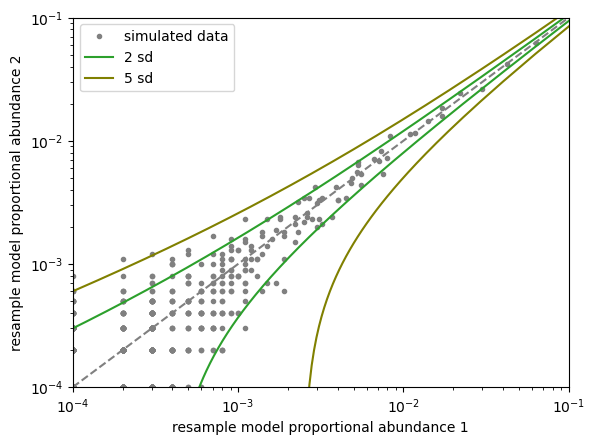

In [235]:
#just do multinomial sampling

#assume a rank abundance
r=np.arange(10**5)+1
pa = r**(-1.1)
pa = pa/pa.sum()

ss=10000

pt1,pt2 = np.random.multinomial(n=ss, pvals=pa, size=2)

plt.loglog(pt1/ss, pt2/ss, '.',color='gray',label = 'simulated data')

sigl=[2,5]
czl=['tab:green','olive']

for i, sig in enumerate(sigl):
    cz=czl[i]
    plt.plot(pa,pa + sig*np.sqrt(ss*pa*(1-pa))/ss, color=cz)
    plt.plot(pa,pa - sig*np.sqrt(ss*pa*(1-pa))/ss, color=cz,label=str(sig)+' sd')

#plt.plot(pa*ss,pa*ss+5*np.sqrt(ss*pa*(1-pa)), color='red')
#plt.plot(pa*ss,pa*ss-5*np.sqrt(ss*pa*(1-pa)), color='red',label='5 sd')

lz=[1e-4,0.1]
plt.xlim(lz)
plt.ylim(lz)
plt.plot(lz,lz, color='gray', linestyle='--')
plt.legend()

plt.xlabel('resample model proportional abundance 1')
plt.ylabel('resample model proportional abundance 2')


In [237]:
n_sims = 500
n_hits = []

for _ in range(n_sims):
    pt1, pt2 = np.random.multinomial(n=ss, pvals=pa, size=2)
    mask = pt1 > 0
    p1_, p2_ = pt1[mask]/ss, pt2[mask]/ss
    z = (p2_ - p1_) / np.sqrt(p1_*(1-p1_)/ss)
    n_hits.append(np.sum(np.abs(z) > 5))

print(np.mean(n_hits))

4.344


In [239]:
from scipy.stats import binomtest

pt1, pt2 = np.random.multinomial(n=ss, pvals=pa, size=2)
mask = pt1 > 0
p1_ = pt1[mask]/ss

pvals_exact = np.array([
    binomtest(k=pt2[mask][i], n=ss, p=p1_[i]).pvalue
    for i in range(mask.sum())
])
print(np.sum(pvals_exact < 5.7e-7))  # exact analog of z>5

1


In [240]:
#need to resample to the same size to start
#then make new df

ss=10**5
c0rs = np.random.multinomial(ss,p0)
c1rs = np.random.multinomial(ss,p1)

#p0p = p0[(p0 > 0) & (p1 > 0)]
#p1p = p1[(p0 > 0) & (p1 > 0)]

p0rs = c0rs/ss
p1rs = c1rs/ss

persist_mask = (p0rs > 0) & (p1rs > 0)

p0p = p0rs[persist_mask]
p1p = p1rs[persist_mask]

clones = df[persist_mask]

clones['p0']=p0p
clones['p1']=p1p

#ss = 1 / (1/sum(ss) + 1/sum(ss))  # harmonic-mean-style effective n
#ssorig = 1 / (1/sum(c0) + 1/sum(c1))  # harmonic-mean-style effective n

clones = clones[['clono','p0','p1']]

clones.head(10)


/var/folders/yk/0drxrmsj07l2thjtfhfyxcxh0000gn/T/ipykernel_43916/3310463267.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clones['p0']=p0p
/var/folders/yk/0drxrmsj07l2thjtfhfyxcxh0000gn/T/ipykernel_43916/3310463267.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clones['p1']=p1p


,clono,p0,p1
0,CASSLDSVYEQYF,0.12256,0.12602
1,CASSLIGVSSYNEQFF,0.01877,0.01715
2,CSARKIGTGGYEQYF,0.01790,0.01573
3,CASSLINSEQYF,0.01769,0.01626
4,CASSLIGTSERNEQFF,0.01237,0.01220
5,CASSPPGTYNEQFF,0.01078,0.01206
6,CASSLIDHPTDTQYF,0.00992,0.00664
7,CAIRLAGATDTQYF,0.00875,0.00695
8,CASTWDRPTGELFF,0.00859,0.00665
9,CASSWDREIQINEQFF,0.00815,0.00600


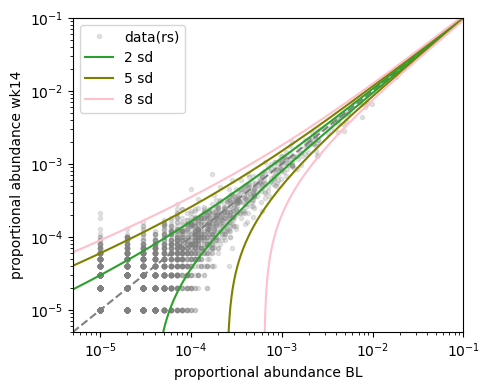

In [241]:
#xy plot scatter with SD curves
# 

plt.figure(figsize=(5,4))
#az=1/np.abs(np.log10(p1p))
plt.loglog(p0p,p1p,'.',alpha=0.2,color='gray',label='data(rs)')

lz=[5e-6,0.1]
plt.xlim(lz)
plt.ylim(lz)
plt.plot(lz,lz, color='gray', linestyle='--')

intpa = np.logspace(np.log10(lz[0]),np.log10(lz[1]),1000)
#intpa = np.linspace(lz[0],lz[1],1000)

sigl=[2,5,8]
czl=['tab:green','olive','pink']

for i, sig in enumerate(sigl):
    cz=czl[i]

    plt.plot(intpa,intpa + sig*np.sqrt(ss*intpa*(1-intpa))/ss, color=cz)
    plt.plot(intpa,intpa - sig*np.sqrt(ss*intpa*(1-intpa))/ss, color=cz,label=str(sig)+' sd')

plt.xlabel('proportional abundance '+tpname[0])
plt.ylabel('proportional abundance '+tpname[1])

plt.legend()
plt.tight_layout()


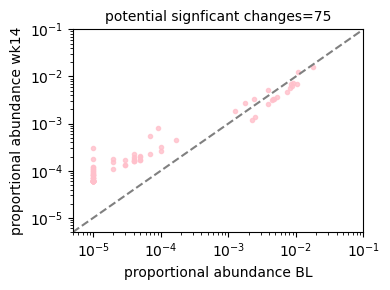

In [230]:
#check how many are outside SD curve
# 

masks = {}
for sig in sigl:
    upper = p0p + sig*np.sqrt(ss*p0p*(1-p0p))/ss
    lower = p0p - sig*np.sqrt(ss*p0p*(1-p0p))/ss
    masks[sig] = (p1p > upper) | (p1p < lower)

signif = masks[5]

clones_sig = clones[signif]

plt.figure(figsize=(4,3))
plt.loglog(clones_sig['p0'],clones_sig['p1'],'.',alpha=0.8,color='pink',label='data(rs)')
lz=[5e-6,0.1]
plt.xlim(lz)
plt.ylim(lz)
plt.plot(lz,lz, color='gray', linestyle='--')

plt.xlabel('proportional abundance '+tpname[0])
plt.ylabel('proportional abundance '+tpname[1])

plt.title('potential signficant changes='+str(len(clones_sig)),fontsize=10)
plt.tight_layout()


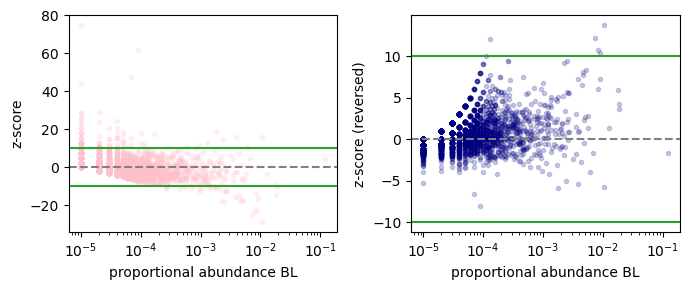

In [231]:
z = (p1p - p0p) / np.sqrt(p0p*(1-p0p)/ssorig)
zrev = (p0p - p1p) / np.sqrt(p1p*(1-p1p)/ss)

sigl=[10]

plt.figure(figsize=(7,3))

plt.subplot(121)
plt.semilogx(p0p, z, '.', alpha=0.2, color='pink')
plt.axhline(0, color='gray', linestyle='--')
for sig, cz in zip(sigl, czl):
    plt.axhline(sig, color=cz)
    plt.axhline(-sig, color=cz)

plt.xlabel('proportional abundance '+tpname[0])
plt.ylabel('z-score')

plt.subplot(122)
plt.semilogx(p0p, zrev, '.', alpha=0.2, color='navy')
plt.axhline(0, color='gray', linestyle='--')
for sig, cz in zip(sigl, czl):
    plt.axhline(sig, color=cz)
    plt.axhline(-sig, color=cz)

plt.xlabel('proportional abundance '+tpname[0])
plt.ylabel('z-score (reversed)')

plt.tight_layout()

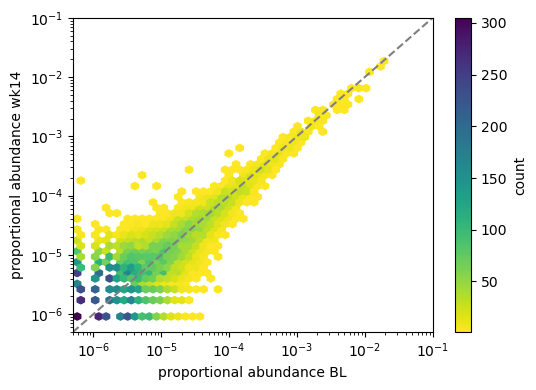

In [ ]:
#xy hexplot

plt.figure(figsize=(5.5,4))
plt.hexbin(p0p, p1p, xscale='log', yscale='log', gridsize=50, mincnt=1, cmap='viridis_r')
plt.colorbar(label='count')

plt.xlim(lz)
plt.ylim(lz)
plt.plot(lz,lz, color='gray', linestyle='--')

plt.xlabel('proportional abundance '+tpname[0])
plt.ylabel('proportional abundance '+tpname[1])
plt.tight_layout()

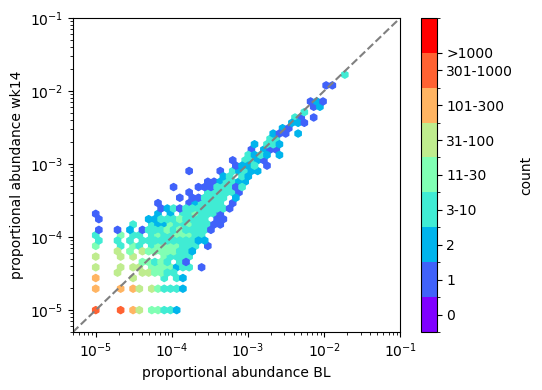

In [ ]:
import matplotlib.colors as mcolors

# bin edges: [0,1), [1,2), [2,3), [3,11), [11,31), [31,101), [101,301), [301,1001), [1001, inf)
bounds = [0, 1, 2, 3, 11, 31, 101, 301, 1001, 1e6]
labels = ['0', '1', '2', '3-10', '11-30', '31-100', '101-300', '301-1000', '>1000']

cmap = plt.get_cmap('rainbow', len(bounds) - 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(5.5,4))
hb = plt.hexbin(p0p, p1p, xscale='log', yscale='log', gridsize=50, mincnt=1, cmap=cmap, norm=norm)

cb = plt.colorbar(hb, label='count')
tick_pos = [(bounds[i] + bounds[i+1]) / 2 for i in range(len(bounds) - 1)]
tick_pos[-1] = bounds[-2] * 1.5  # last bin is huge, place tick just above its lower edge
cb.set_ticks(tick_pos)
cb.set_ticklabels(labels)

plt.xlim(lz)
plt.ylim(lz)
plt.plot(lz, lz, color='gray', linestyle='--')

plt.xlabel('proportional abundance '+tpname[0])
plt.ylabel('proportional abundance '+tpname[1])
plt.tight_layout()

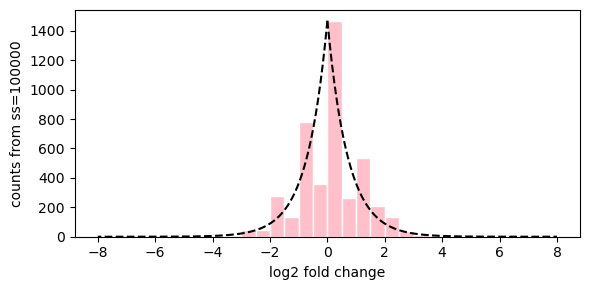

In [223]:
plt.figure(figsize=(6,3))
H = plt.hist(np.log2(p1p/p0p),color='pink',bins=np.arange(-8,8,0.5),align='mid',ec='white',histtype='bar')

#model of distribution?
x=np.linspace(0,8,100)
plt.plot(x,np.exp(-x*1.4)*np.max(H[0]),color='k',ls='--')
plt.plot(-x,np.exp(-x*1.4)*np.max(H[0]),color='k',ls='--')

#plt.semilogy()
plt.xlabel('log2 fold change')
plt.ylabel('counts from ss='+str(ss))

plt.tight_layout()

/Users/dreeves/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


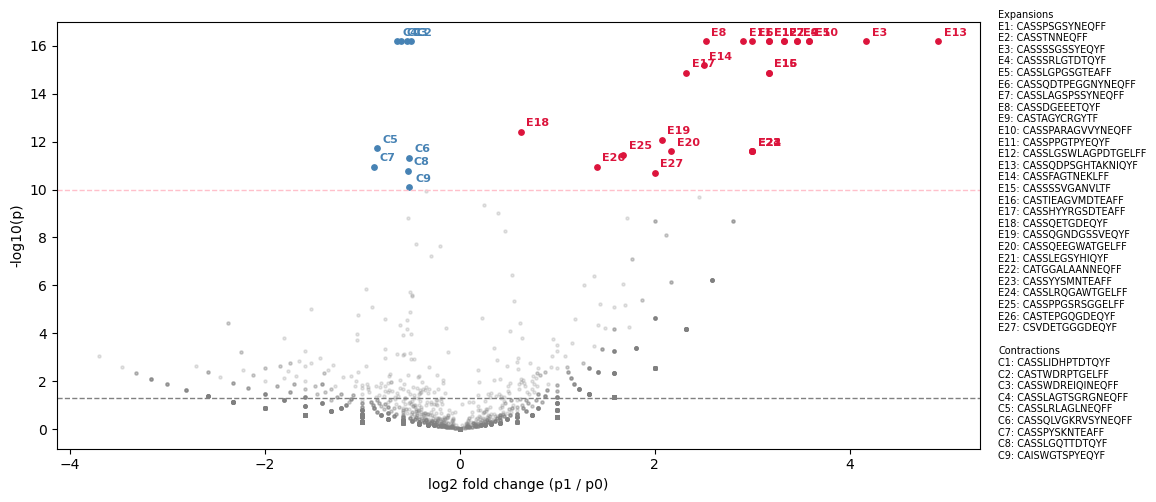

In [233]:
from scipy.stats import norm

dfp = clones.copy()

dfp['fc'] = np.log2(dfp['p1'] / dfp['p0'])
dfp['z'] = (dfp['p1'] - dfp['p0']) / np.sqrt(dfp['p0']*(1-dfp['p0'])/ss)
dfp['pval'] = 2 * (1 - norm.cdf(np.abs(dfp['z'])))
dfp['neglogp'] = -np.log10(dfp['pval'])
finite_max = dfp.loc[np.isfinite(dfp['neglogp']), 'neglogp'].max()
dfp['neglogp'] = dfp['neglogp'].replace(np.inf, finite_max + 1)

sig = dfp[dfp['neglogp'] > 10].copy()
exp = sig[sig['fc'] > 0].sort_values('neglogp', ascending=False).reset_index(drop=True)
con = sig[sig['fc'] < 0].sort_values('neglogp', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.scatter(dfp['fc'], dfp['neglogp'], s=5, alpha=0.2, color='gray')
plt.scatter(exp['fc'], exp['neglogp'], s=15, color='crimson')
plt.scatter(con['fc'], con['neglogp'], s=15, color='steelblue')

for i, row in exp.iterrows():
    plt.annotate(f'E{i+1}', (row['fc'], row['neglogp']),
                 fontsize=8, fontweight='bold', color='crimson',
                 xytext=(4,4), textcoords='offset points')

for i, row in con.iterrows():
    plt.annotate(f'C{i+1}', (row['fc'], row['neglogp']),
                 fontsize=8, fontweight='bold', color='steelblue',
                 xytext=(4,4), textcoords='offset points')

plt.axhline(10, color='pink', ls='--', lw=1)
plt.axhline(-np.log10(0.05), color='gray', ls='--', lw=1)
plt.xlabel('log2 fold change (p1 / p0)')
plt.ylabel('-log10(p)')

exp_lines = [f'E{i+1}: {row["clono"]}' for i, row in exp.iterrows()]
con_lines = [f'C{i+1}: {row["clono"]}' for i, row in con.iterrows()]
legend_text = 'Expansions\n' + '\n'.join(exp_lines) + '\n\nContractions\n' + '\n'.join(con_lines)
plt.gcf().text(1.02, 0.5, legend_text, fontsize=7, va='center', transform=plt.gca().transAxes)

plt.tight_layout()

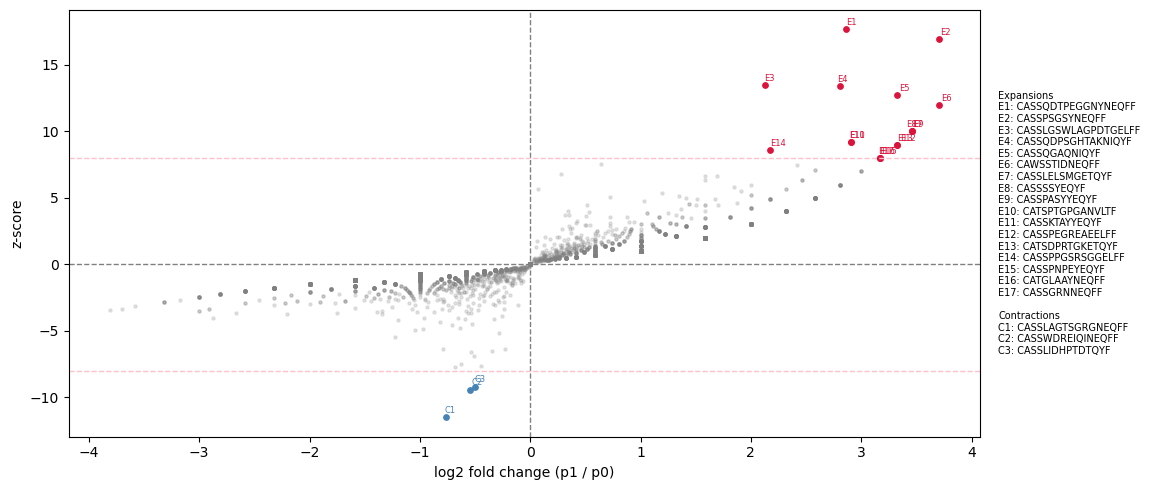

In [222]:
zthresh = 8
jit=0.5

z10 = dfp[dfp['z'].abs() > zthresh].copy()

exp = z10[z10['z'] > 0].sort_values('z', ascending=False).reset_index(drop=True)
con = z10[z10['z'] < 0].sort_values('z', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.scatter(dfp['fc'], dfp['z'], s=5, alpha=0.2, color='gray')
plt.scatter(exp['fc'], exp['z'], s=15, color='crimson')
plt.scatter(con['fc'], con['z'], s=15, color='steelblue')

for i, row in exp.iterrows():
    plt.annotate(f'E{i+1}', (row['fc'], row['z']),
                 fontsize=6, color='crimson',
                 xytext=[np.random.normal(0,jit)*3,3], textcoords='offset points')

for i, row in con.iterrows():
    plt.annotate(f'C{i+1}', (row['fc'], row['z']),
                 fontsize=6, color='steelblue',
                 xytext=[np.random.normal(0,jit)*3,3], textcoords='offset points')

plt.axhline(0, color='gray', ls='--', lw=1)
plt.axvline(0, color='gray', ls='--', lw=1)
plt.axhline(zthresh, color='pink', ls='--', lw=1)
plt.axhline(-zthresh, color='pink', ls='--', lw=1)
plt.xlabel('log2 fold change (p1 / p0)')
plt.ylabel('z-score')

exp_lines = [f'E{i+1}: {row["clono"]}' for i, row in exp.iterrows()]
con_lines = [f'C{i+1}: {row["clono"]}' for i, row in con.iterrows()]
legend_text = 'Expansions\n' + '\n'.join(exp_lines) + '\n\nContractions\n' + '\n'.join(con_lines)
plt.gcf().text(1.02, 0.5, legend_text, fontsize=7, va='center', transform=plt.gca().transAxes)

plt.tight_layout()

In [243]:
#final function to do this

def clone_call(c0, c1, ss, rho=0.0, alpha_sig=0.05):

    p0 = c0/ss
    pvals = np.empty(len(p0))

    for i in range(len(p0)):

        if rho <= 0:
            # exact binomial null: k1 ~ Binomial(n1, p0)
            dist = st.binom(c1[i], p0[i])
        else:
            # exact beta-binomial null: k1 ~ BetaBinomial(n1, alpha, beta)
            a = p0[i] * (1/rho - 1)
            b = (1 - p0[i]) * (1/rho - 1)
            dist = st.betabinom(c1[i], a, b)

        mean = dist.mean()
        if c1[i] >= mean:
            pvals[i] = 2 * min(dist.sf(c1[i] - 1), 0.5)  # P(K >= k1)
        else:
            pvals[i] = 2 * min(dist.cdf(c1[i]), 0.5)      # P(K <= k1)

    call = np.where(
        pvals >= alpha_sig, 'ns',
        np.where(p1 > p0, 'expansion', 'contraction')
    )

    return pvals

In [246]:
c0 = df['counts_pre']
c1 = df['counts_post']

clone_call(c0, c1, ss=1000, rho=0.0, alpha_sig=0.05)

array([nan, nan, nan, ...,  0.,  0.,  0.])